In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("/content/ecommerce_sales.csv")

print("===== FIRST 5 RECORDS =====")
display(df.head())

print("\n===== DATASET SHAPE =====")
print(df.shape)

print("\n===== COLUMN NAMES =====")
print(df.columns.tolist())

print("\n===== DATA TYPES =====")
print(df.dtypes)

print("\n===== MISSING VALUES =====")
print(df.isnull().sum())

print("\n===== DUPLICATE RECORDS =====")
print("Duplicates:", df.duplicated().sum())

print("\n===== DESCRIPTIVE STATISTICS =====")
display(df.describe())

===== FIRST 5 RECORDS =====


,Order_ID,Order_Date,Customer_ID,Product,Category,Region,Quantity,Sales,Profit,Payment_Mode
0,1001,2026-01-02,C001,Laptop,Electronics,Pune,2,100000,15000,UPI
1,1002,2026-01-04,C002,Mouse,Accessories,Mumbai,5,5000,1500,Credit Card
2,1003,2026-01-06,C003,Keyboard,Accessories,Pune,3,4500,1200,UPI
3,1004,2026-01-08,C004,Monitor,Electronics,Nashik,2,30000,5000,Debit Card
4,1005,2026-01-10,C005,Laptop,Electronics,Mumbai,1,50000,7500,Credit Card



===== DATASET SHAPE =====
(30, 10)

===== COLUMN NAMES =====
['Order_ID', 'Order_Date', 'Customer_ID', 'Product', 'Category', 'Region', 'Quantity', 'Sales', 'Profit', 'Payment_Mode']

===== DATA TYPES =====
Order_ID         int64
Order_Date      object
Customer_ID     object
Product         object
Category        object
Region          object
Quantity         int64
Sales            int64
Profit           int64
Payment_Mode    object
dtype: object

===== MISSING VALUES =====
Order_ID        0
Order_Date      0
Customer_ID     0
Product         0
Category        0
Region          0
Quantity        0
Sales           0
Profit          0
Payment_Mode    0
dtype: int64

===== DUPLICATE RECORDS =====
Duplicates: 0

===== DESCRIPTIVE STATISTICS =====


,Order_ID,Quantity,Sales,Profit
count,30.000000,30.000000,30.000000,30.000000
mean,1015.500000,3.866667,33266.666667,5600.000000
std,8.803408,2.417370,32924.085444,4654.771375
min,1001.000000,1.000000,4500.000000,1200.000000
25%,1008.250000,2.000000,6000.000000,1800.000000
50%,1015.500000,3.000000,20000.000000,4000.000000
75%,1022.750000,5.000000,50000.000000,7500.000000
max,1030.000000,10.000000,100000.000000,15000.000000


Task 3

In [ ]:
# ==========================================
# TASK 3 - DATA CLEANING & PREPARATION
# ==========================================

# Convert Order_Date to datetime
df["Order_Date"] = pd.to_datetime(df["Order_Date"])

# Check missing values
print("Missing values before cleaning:")
print(df.isnull().sum())

# Remove duplicate records
df = df.drop_duplicates()

# Check for incorrect numeric values
print("\nNegative Sales:", (df["Sales"] < 0).sum())
print("Negative Profit:", (df["Profit"] < 0).sum())
print("Zero Quantity:", (df["Quantity"] == 0).sum())

# Final dataset information
print("\nDataset after cleaning:")
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

print("\nData types after cleaning:")
print(df.dtypes)

print("\nDuplicate records after cleaning:", df.duplicated().sum())

print("\nMissing values after cleaning:")
print(df.isnull().sum())

display(df.head())

Missing values before cleaning:
Order_ID        0
Order_Date      0
Customer_ID     0
Product         0
Category        0
Region          0
Quantity        0
Sales           0
Profit          0
Payment_Mode    0
dtype: int64

Negative Sales: 0
Negative Profit: 0
Zero Quantity: 0

Dataset after cleaning:
Rows: 30
Columns: 10

Data types after cleaning:
Order_ID                 int64
Order_Date      datetime64[ns]
Customer_ID             object
Product                 object
Category                object
Region                  object
Quantity                 int64
Sales                    int64
Profit                   int64
Payment_Mode            object
dtype: object

Duplicate records after cleaning: 0

Missing values after cleaning:
Order_ID        0
Order_Date      0
Customer_ID     0
Product         0
Category        0
Region          0
Quantity        0
Sales           0
Profit          0
Payment_Mode    0
dtype: int64


,Order_ID,Order_Date,Customer_ID,Product,Category,Region,Quantity,Sales,Profit,Payment_Mode
0,1001,2026-01-02,C001,Laptop,Electronics,Pune,2,100000,15000,UPI
1,1002,2026-01-04,C002,Mouse,Accessories,Mumbai,5,5000,1500,Credit Card
2,1003,2026-01-06,C003,Keyboard,Accessories,Pune,3,4500,1200,UPI
3,1004,2026-01-08,C004,Monitor,Electronics,Nashik,2,30000,5000,Debit Card
4,1005,2026-01-10,C005,Laptop,Electronics,Mumbai,1,50000,7500,Credit Card


Task 4 — Exploratory Data Analysis (EDA)


===== CORRELATION MATRIX =====


,Quantity,Sales,Profit
Quantity,1.000000,-0.577502,-0.526482
Sales,-0.577502,1.000000,0.997442
Profit,-0.526482,0.997442,1.000000


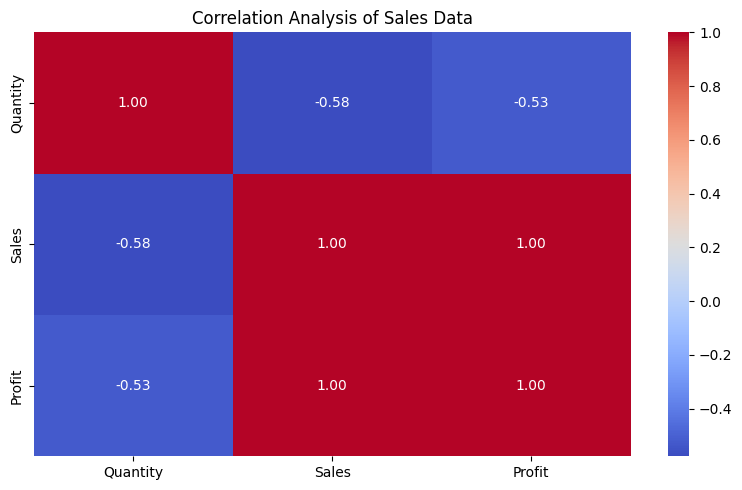

In [ ]:
# ==========================================
# TASK 4 - EXPLORATORY DATA ANALYSIS
# Correlation Analysis
# ==========================================

numeric_columns = ["Quantity", "Sales", "Profit"]

correlation_matrix = df[numeric_columns].corr()

print("===== CORRELATION MATRIX =====")
display(correlation_matrix)

# Correlation Heatmap
plt.figure(figsize=(8, 5))
sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Analysis of Sales Data")
plt.tight_layout()
plt.show()

STEP 4B — Outlier Detection using IQR

In [ ]:
# ==========================================
# OUTLIER DETECTION USING IQR
# ==========================================

Q1 = df["Sales"].quantile(0.25)
Q3 = df["Sales"].quantile(0.75)

IQR = Q3 - Q1

lower_limit = Q1 - 1.5 * IQR
upper_limit = Q3 + 1.5 * IQR

print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)
print("Lower Limit:", lower_limit)
print("Upper Limit:", upper_limit)

outliers = df[
    (df["Sales"] < lower_limit) |
    (df["Sales"] > upper_limit)
]

print("\n===== SALES OUTLIERS =====")
print("Number of outliers:", len(outliers))

display(outliers)

Q1: 6000.0
Q3: 50000.0
IQR: 44000.0
Lower Limit: -60000.0
Upper Limit: 116000.0

===== SALES OUTLIERS =====
Number of outliers: 0


,Order_ID,Order_Date,Customer_ID,Product,Category,Region,Quantity,Sales,Profit,Payment_Mode


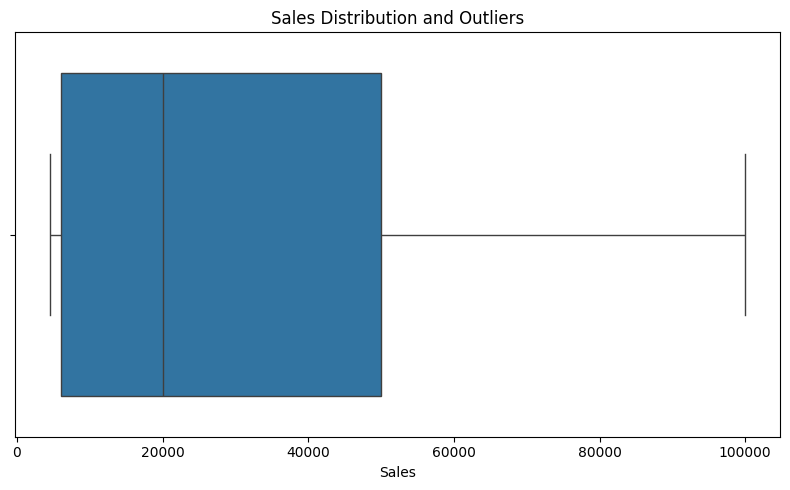

In [ ]:
# Box Plot for Sales

plt.figure(figsize=(8, 5))
sns.boxplot(x=df["Sales"])

plt.title("Sales Distribution and Outliers")
plt.xlabel("Sales")

plt.tight_layout()
plt.show()

STEP 4C — Find important patterns

In [ ]:
# ==========================================
# TASK 4 - PATTERNS AND TRENDS
# ==========================================

print("===== SALES BY CATEGORY =====")
category_sales = df.groupby("Category")["Sales"].sum().sort_values(ascending=False)
display(category_sales)

print("\n===== PROFIT BY CATEGORY =====")
category_profit = df.groupby("Category")["Profit"].sum().sort_values(ascending=False)
display(category_profit)

print("\n===== SALES BY REGION =====")
region_sales = df.groupby("Region")["Sales"].sum().sort_values(ascending=False)
display(region_sales)

print("\n===== PROFIT BY REGION =====")
region_profit = df.groupby("Region")["Profit"].sum().sort_values(ascending=False)
display(region_profit)

print("\n===== SALES BY PRODUCT =====")
product_sales = df.groupby("Product")["Sales"].sum().sort_values(ascending=False)
display(product_sales)

print("\n===== MONTHLY SALES TREND =====")
monthly_sales = df.groupby(
    df["Order_Date"].dt.to_period("M").astype(str)
)["Sales"].sum()

display(monthly_sales)

print("\n===== EDA SUMMARY =====")
print("Highest sales category:", category_sales.index[0])
print("Highest sales region:", region_sales.index[0])
print("Highest sales product:", product_sales.index[0])
print("Highest sales month:", monthly_sales.idxmax())

===== SALES BY CATEGORY =====


,Sales
Category,
Electronics,900000
Accessories,98000



===== PROFIT BY CATEGORY =====


,Profit
Category,
Electronics,140000
Accessories,28000



===== SALES BY REGION =====


...


===== SALES BY PRODUCT =====


,Sales
Product,
Laptop,600000
Monitor,300000
Mouse,56000
Keyboard,42000



===== MONTHLY SALES TREND =====


,Sales
Order_Date,
2026-01,354500
2026-02,275000
2026-03,368500



===== EDA SUMMARY =====
Highest sales category: Electronics
Highest sales region: Nashik
Highest sales product: Laptop
Highest sales month: 2026-03


Task 5 — Data Visualization

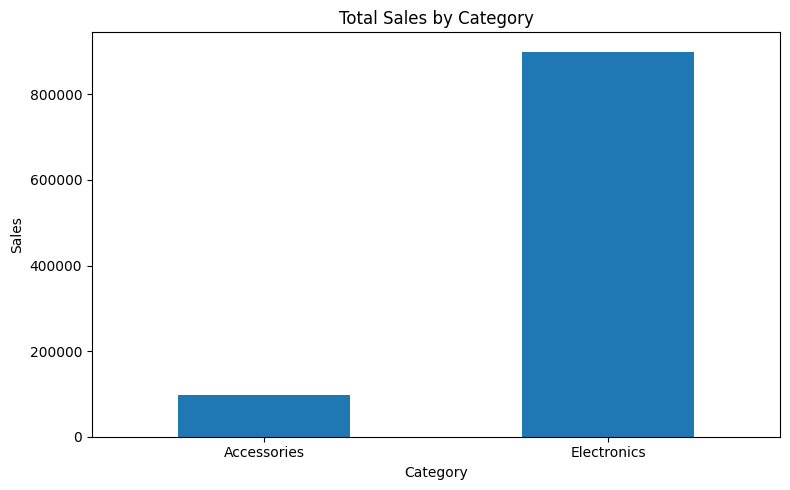

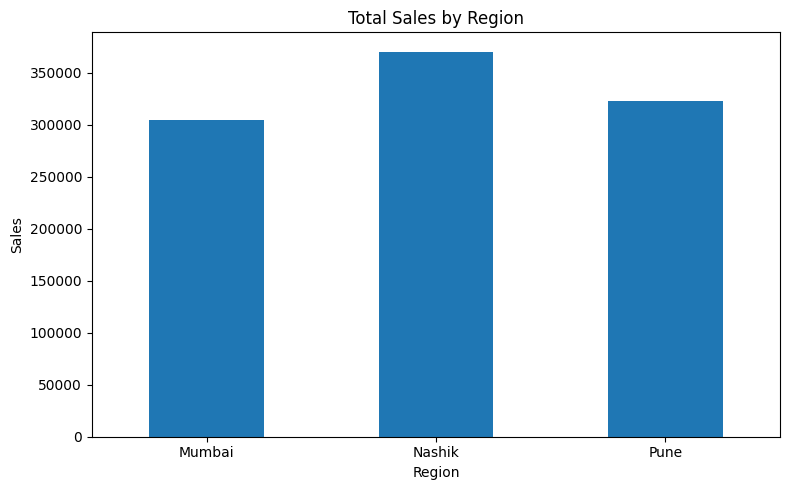

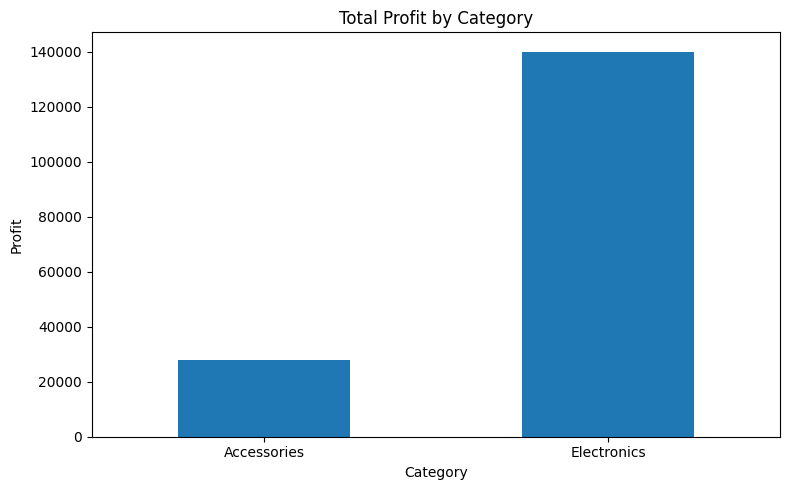

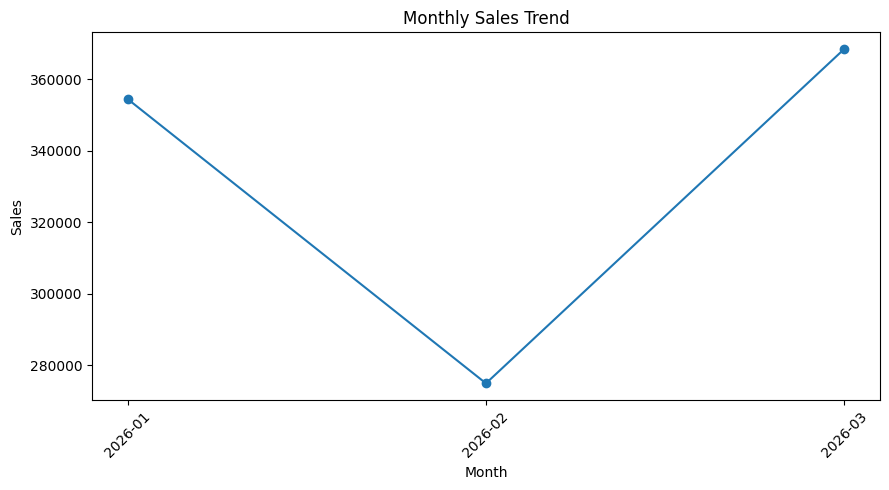

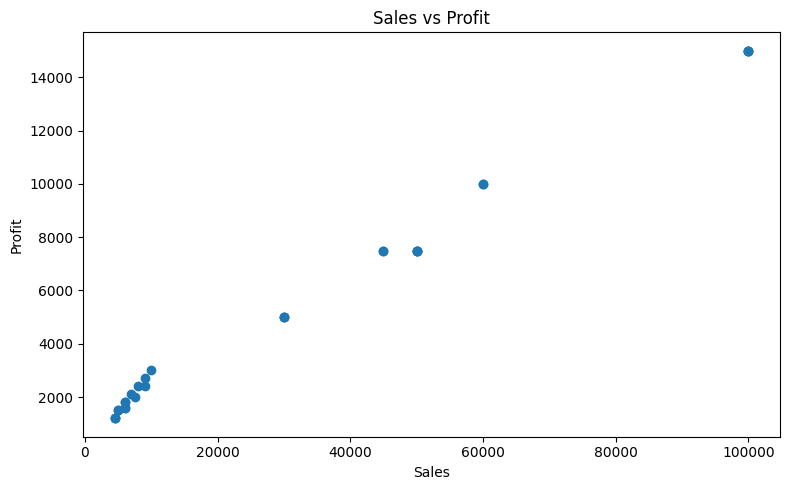

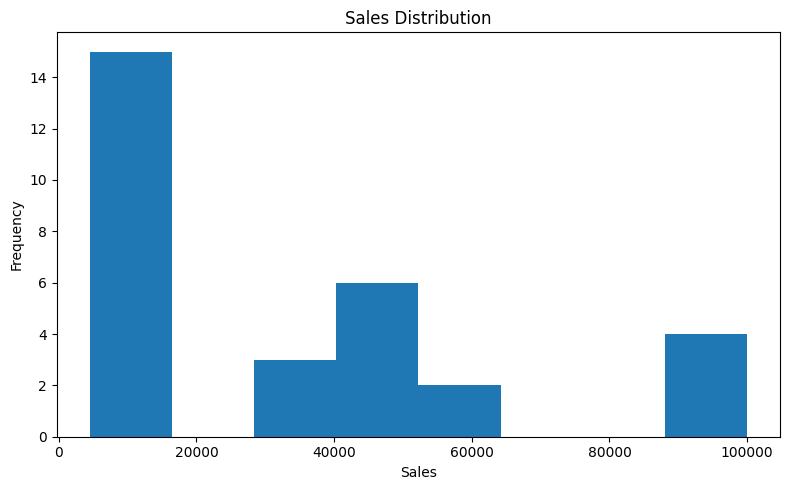

6 VISUALIZATIONS CREATED SUCCESSFULLY


In [ ]:
# ==========================================
# TASK 5 - DATA VISUALIZATION
# ==========================================

import os

# Create folder for visualizations
os.makedirs("/content/visualizations", exist_ok=True)

# ------------------------------------------
# 1. Sales by Category
# ------------------------------------------

category_sales = df.groupby("Category")["Sales"].sum()

plt.figure(figsize=(8, 5))
category_sales.plot(kind="bar")
plt.title("Total Sales by Category")
plt.xlabel("Category")
plt.ylabel("Sales")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig("/content/visualizations/sales_by_category.png")
plt.show()


# ------------------------------------------
# 2. Sales by Region
# ------------------------------------------

region_sales = df.groupby("Region")["Sales"].sum()

plt.figure(figsize=(8, 5))
region_sales.plot(kind="bar")
plt.title("Total Sales by Region")
plt.xlabel("Region")
plt.ylabel("Sales")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig("/content/visualizations/sales_by_region.png")
plt.show()


# ------------------------------------------
# 3. Profit by Category
# ------------------------------------------

category_profit = df.groupby("Category")["Profit"].sum()

plt.figure(figsize=(8, 5))
category_profit.plot(kind="bar")
plt.title("Total Profit by Category")
plt.xlabel("Category")
plt.ylabel("Profit")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig("/content/visualizations/profit_by_category.png")
plt.show()


# ------------------------------------------
# 4. Monthly Sales Trend
# ------------------------------------------

monthly_sales = df.groupby(
    df["Order_Date"].dt.to_period("M").astype(str)
)["Sales"].sum()

plt.figure(figsize=(9, 5))
plt.plot(monthly_sales.index, monthly_sales.values, marker="o")
plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Sales")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("/content/visualizations/monthly_sales_trend.png")
plt.show()


# ------------------------------------------
# 5. Sales vs Profit
# ------------------------------------------

plt.figure(figsize=(8, 5))
plt.scatter(df["Sales"], df["Profit"])
plt.title("Sales vs Profit")
plt.xlabel("Sales")
plt.ylabel("Profit")
plt.tight_layout()
plt.savefig("/content/visualizations/sales_vs_profit.png")
plt.show()


# ------------------------------------------
# 6. Sales Distribution
# ------------------------------------------

plt.figure(figsize=(8, 5))
plt.hist(df["Sales"], bins=8)
plt.title("Sales Distribution")
plt.xlabel("Sales")
plt.ylabel("Frequency")
plt.tight_layout()
plt.savefig("/content/visualizations/sales_distribution.png")
plt.show()

print("===================================")
print("6 VISUALIZATIONS CREATED SUCCESSFULLY")
print("===================================")

In [ ]:
import pandas as pd

data = {
    "Order_ID": range(1001, 1031),
    "Order_Date": [
        "2026-01-02","2026-01-04","2026-01-06","2026-01-08","2026-01-10",
        "2026-01-12","2026-01-15","2026-01-18","2026-01-20","2026-01-22",
        "2026-02-02","2026-02-05","2026-02-08","2026-02-11","2026-02-14",
        "2026-02-18","2026-02-21","2026-02-24","2026-02-26","2026-02-28",
        "2026-03-03","2026-03-06","2026-03-09","2026-03-12","2026-03-15",
        "2026-03-18","2026-03-21","2026-03-24","2026-03-27","2026-03-30"
    ],
    "Customer_ID": [f"C{i:03d}" for i in range(1,31)],
    "Product": (["Laptop","Mouse","Keyboard","Monitor"] * 7) + ["Mouse","Keyboard"],
    "Category": (["Electronics","Accessories","Accessories","Electronics"] * 7) + ["Accessories","Accessories"],
    "Region": (["Pune","Mumbai","Pune","Nashik","Mumbai","Nashik","Pune","Mumbai","Nashik","Pune"] * 3),
    "Quantity": [2,5,3,2,1,8,4,3,2,6,1,5,2,10,1,3,4,7,1,4,3,9,2,6,2,5,2,3,4,6],
    "Sales": [100000,5000,4500,30000,50000,8000,6000,45000,100000,6000,
              50000,7500,30000,10000,50000,4500,60000,7000,50000,6000,
              45000,9000,100000,9000,30000,5000,100000,4500,60000,6000],
    "Profit": [15000,1500,1200,5000,7500,2400,1600,7500,15000,1800,
               7500,2000,5000,3000,7500,1200,10000,2100,7500,1600,
               7500,2700,15000,2400,5000,1500,15000,1200,10000,1800],
    "Payment_Mode": [
        "UPI","Credit Card","UPI","Debit Card","Credit Card",
        "UPI","Cash","Credit Card","UPI","Debit Card",
        "UPI","Cash","Credit Card","UPI","Debit Card",
        "Cash","Credit Card","UPI","Credit Card","Debit Card",
        "UPI","Cash","Credit Card","UPI","Debit Card",
        "Cash","UPI","Credit Card","UPI","Debit Card"
    ]
}

df = pd.DataFrame(data)

df.to_csv("/content/ecommerce_sales.csv", index=False)

print("CSV created successfully!")
print(df.shape)
display(df.head())

CSV created successfully!
(30, 10)


,Order_ID,Order_Date,Customer_ID,Product,Category,Region,Quantity,Sales,Profit,Payment_Mode
0,1001,2026-01-02,C001,Laptop,Electronics,Pune,2,100000,15000,UPI
1,1002,2026-01-04,C002,Mouse,Accessories,Mumbai,5,5000,1500,Credit Card
2,1003,2026-01-06,C003,Keyboard,Accessories,Pune,3,4500,1200,UPI
3,1004,2026-01-08,C004,Monitor,Electronics,Nashik,2,30000,5000,Debit Card
4,1005,2026-01-10,C005,Laptop,Electronics,Mumbai,1,50000,7500,Credit Card


In [ ]:
import os

print(os.path.exists("/content/ecommerce_sales.csv"))
print(os.listdir("/content"))

True
['.config', 'ecommerce_sales.csv', 'sample_data']


In [ ]:
df["Order_Date"] = pd.to_datetime(df["Order_Date"], errors="coerce")

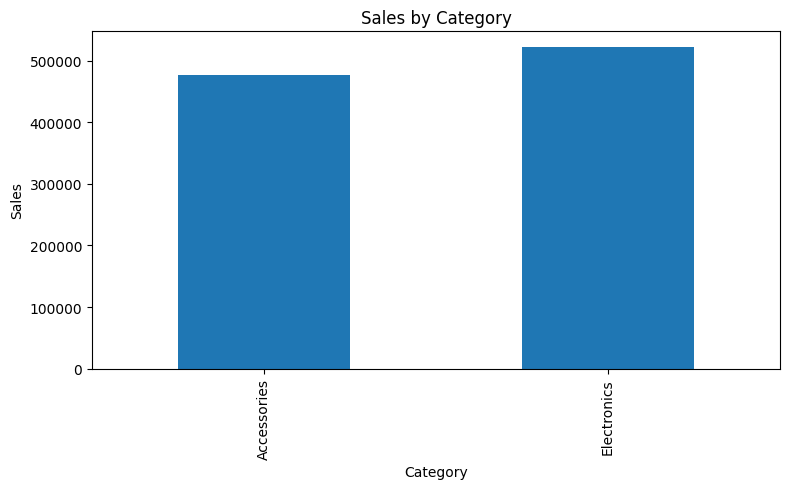

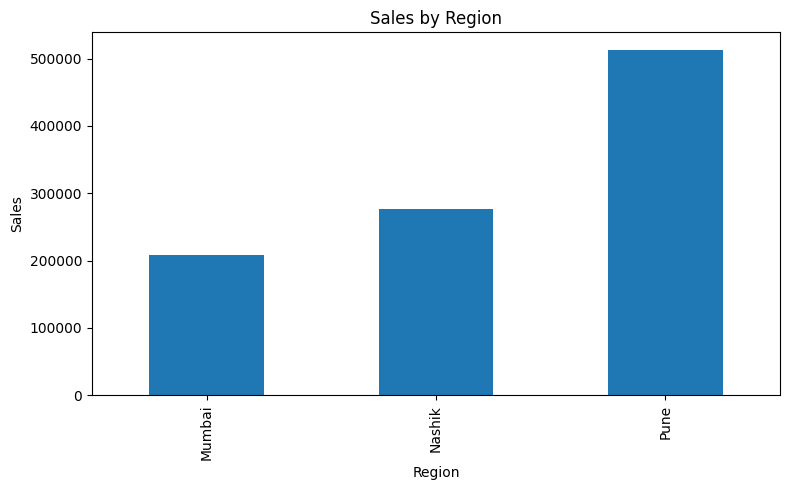

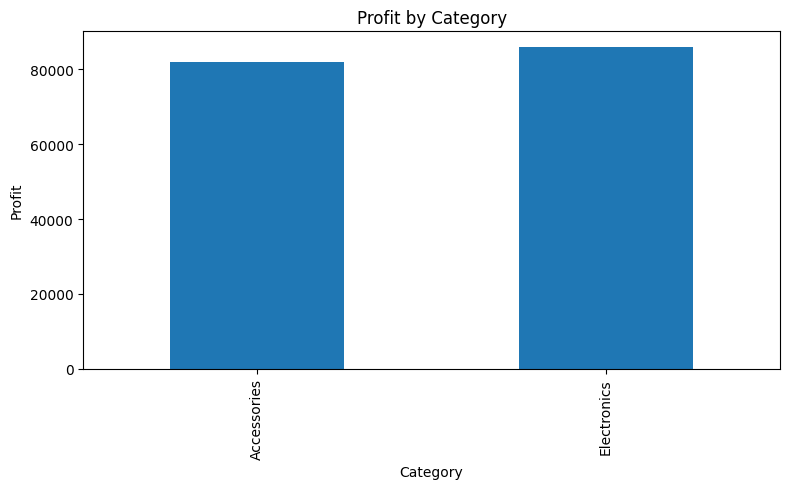

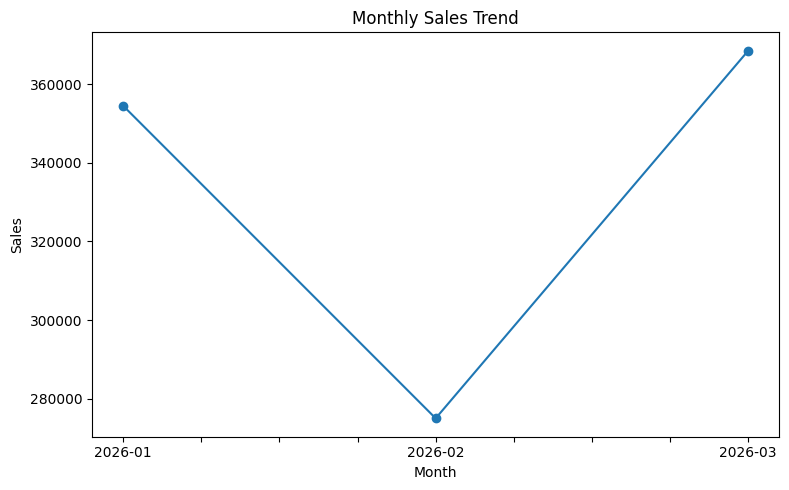

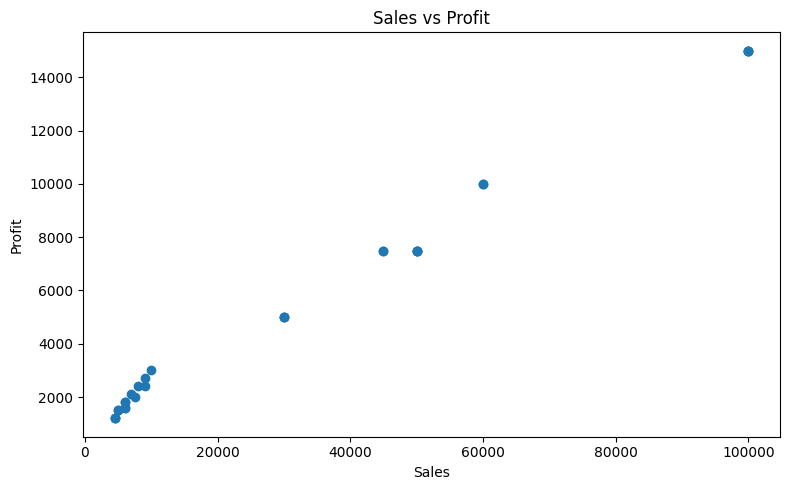

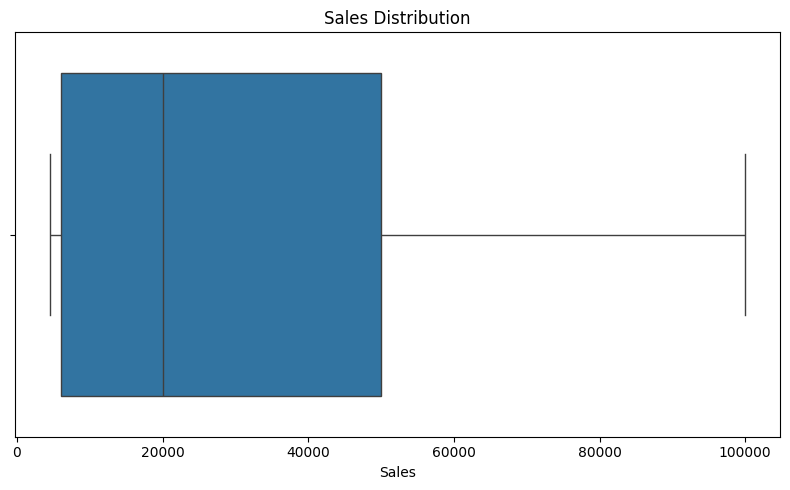

✅ All 6 visualizations saved!


In [ ]:
import os
import matplotlib.pyplot as plt
import seaborn as sns

os.makedirs("/content/visualizations", exist_ok=True)

# 1. Sales by Category
plt.figure(figsize=(8,5))
df.groupby("Category")["Sales"].sum().plot(kind="bar")
plt.title("Sales by Category")
plt.xlabel("Category")
plt.ylabel("Sales")
plt.tight_layout()
plt.savefig("/content/visualizations/sales_by_category.png")
plt.show()

# 2. Sales by Region
plt.figure(figsize=(8,5))
df.groupby("Region")["Sales"].sum().plot(kind="bar")
plt.title("Sales by Region")
plt.xlabel("Region")
plt.ylabel("Sales")
plt.tight_layout()
plt.savefig("/content/visualizations/sales_by_region.png")
plt.show()

# 3. Profit by Category
plt.figure(figsize=(8,5))
df.groupby("Category")["Profit"].sum().plot(kind="bar")
plt.title("Profit by Category")
plt.xlabel("Category")
plt.ylabel("Profit")
plt.tight_layout()
plt.savefig("/content/visualizations/profit_by_category.png")
plt.show()

# 4. Monthly Sales Trend
monthly_sales = df.groupby(df["Order_Date"].dt.to_period("M").astype(str))["Sales"].sum()

plt.figure(figsize=(8,5))
monthly_sales.plot(kind="line", marker="o")
plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Sales")
plt.tight_layout()
plt.savefig("/content/visualizations/monthly_sales_trend.png")
plt.show()

# 5. Sales vs Profit
plt.figure(figsize=(8,5))
plt.scatter(df["Sales"], df["Profit"])
plt.title("Sales vs Profit")
plt.xlabel("Sales")
plt.ylabel("Profit")
plt.tight_layout()
plt.savefig("/content/visualizations/sales_vs_profit.png")
plt.show()

# 6. Sales Distribution
plt.figure(figsize=(8,5))
sns.boxplot(x=df["Sales"])
plt.title("Sales Distribution")
plt.xlabel("Sales")
plt.tight_layout()
plt.savefig("/content/visualizations/sales_distribution.png")
plt.show()

print("✅ All 6 visualizations saved!")

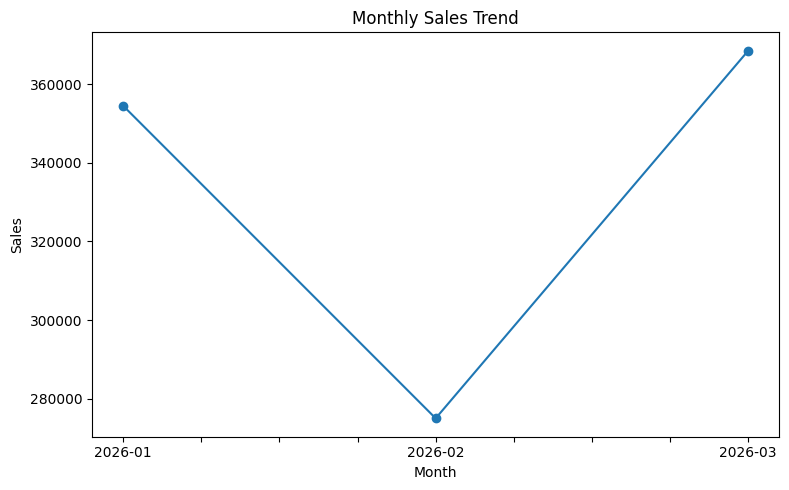

In [ ]:
monthly_sales = df.groupby(
    df["Order_Date"].dt.to_period("M").astype(str)
)["Sales"].sum()

plt.figure(figsize=(8,5))
monthly_sales.plot(kind="line", marker="o")
plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Sales")
plt.tight_layout()
plt.savefig("/content/visualizations/monthly_sales_trend.png")
plt.show()

In [ ]:
!zip -r /content/visualizations.zip /content/visualizations

  adding: content/visualizations/ (stored 0%)
  adding: content/visualizations/sales_distribution.png (deflated 27%)
  adding: content/visualizations/sales_by_category.png (deflated 23%)
  adding: content/visualizations/sales_vs_profit.png (deflated 20%)
  adding: content/visualizations/sales_by_region.png (deflated 23%)
  adding: content/visualizations/monthly_sales_trend.png (deflated 12%)
  adding: content/visualizations/profit_by_category.png (deflated 22%)


In [ ]:
from google.colab import files
files.download('/content/visualizations.zip')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>